# Data Comparison

This is a jupyter notebook to check the difference in the input data between slightly different kinematic events. This can be used to check if the collinear mass approximation is better suited for VBF events or ones from the Drell-Yan process

In [1]:
import sys
import subprocess
from enum import Enum  
import h5py
import numpy as np
from numpy.lib import recfunctions as rfn
import pandas as pd
import torch
import polars as pl
import math
import matplotlib.pyplot as plt
from numpy.lib import recfunctions as rfn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch
import os
from sklearn.metrics import r2_score 
from sklearn.preprocessing import FunctionTransformer
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.colors as colors


result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "h5py", "pandas", "numpy", "torch", "torch_optimizer", "polars", "matplotlib", "scikit-learn", "torchinfo", "omegaConf", "loguru", "lightning"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

if result.returncode != 0:
    print("Installation failed.")

import importlib

def read_h5_data(file_name):
    with h5py.File(file_name, 'r') as file:
        particles = file['INPUTS']['PARTICLES'][:, :42]  # First 43 columns/features
        metadata = file['METADATA']['EVENT_DATA'][:]

        signal_inputs = rfn.structured_to_unstructured(particles)

        particles_keys = list(file['INPUTS']['PARTICLES'].dtype.names)[:42]
        input_keys_dict = {key: idx for idx, key in enumerate(particles_keys)}

    return signal_inputs, metadata, input_keys_dict

def load_multiple_h5(files):
    all_signals = []
    all_metadata = []
    input_keys_dict = None

    for f in files:
        signals, metadata, keys_dict = read_h5_data(f)

        print(f'File: {f} has {len(signals)} events')
        all_signals.append(signals)
        all_metadata.append(metadata)
        if input_keys_dict is None:
            input_keys_dict = keys_dict

    combined_signals = np.vstack(all_signals)
    combined_metadata = np.vstack(all_metadata)

    return combined_signals, combined_metadata, input_keys_dict

def flat_inputs(input_array, n_particles, feature_indices=None):
    if feature_indices is None:
        feature_indices = list(range(input_array.shape[2]))  # Use all features if none specified

    # Select specific particles and features
    output_array = input_array[:, :n_particles, feature_indices]
    
    # Transpose to (samples, features, particles)
    output_array = output_array.transpose(0, 2, 1)
    
    # Flatten to (samples, n_particles * n_features_selected)
    return output_array.reshape(-1, n_particles * len(feature_indices))

class MetadataIndex(Enum):
    # EVENT_NUMBER = 0 No need to assing this 
    OMEGA = 1
    MZ_RECO = 2
    MZ_TRUTH = 3
    MMC_MZ = 4
    OPENING_ANGLE = 5
    LEP_MET_ANGLE_SIGNED = 6
    IS_MET_INSIDE = 7
    IS_EVENT_TPG_HADEL = 8
    TAU_GOOD_ID = 9
    TAU_GOOD_N_TRACKS = 10
    TAU_NN_DECAY = 11
    THREE_BODY_TRAN_MASS = 12
    M3_STAR = 13

def load_and_clean_data(files):
    signal_inputs, metadata_inputs, input_keys_dict = load_multiple_h5(files)
    valid = metadata_inputs[:, MetadataIndex.MMC_MZ.value] != 0
    signal_inputs = signal_inputs[valid]
    metadata_inputs = metadata_inputs[valid]

    return signal_inputs, metadata_inputs, input_keys_dict

# Check which files are available and the data in them

In [2]:
import glob

# Get all .h5 files in the H5Dumper directory
files = glob.glob('../../../H5Dumper/*.h5')

files.sort()
signal_inputs, metadata_inputs, input_keys_dict = load_multiple_h5(files)

for f in files:
    print(f)


with h5py.File('../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5', 'r') as file:
    columns = [name.decode() for name in file['METADATA']['EVENT_DATA'].attrs['columns']]
    print(columns)

File: ../../../H5Dumper/VBFHtautau_346190_mc20a_fullsim.h5 has 1069 events
File: ../../../H5Dumper/VBFHtautau_346190_mc20d_fullsim.h5 has 1634 events
File: ../../../H5Dumper/VBFHtautau_346190_mc20e_fullsim.h5 has 2282 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20a_fullsim.h5 has 47304 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20d_fullsim.h5 has 58323 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20e_fullsim.h5 has 80528 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20a_fullsim.h5 has 47206 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20d_fullsim.h5 has 57919 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20e_fullsim.h5 has 80595 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20a_fullsim.h5 has 526 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20d_fullsim.h5 has 755 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20e_fullsim.h5 has 1016 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5 has 24532 events
File: ../../..

In [3]:
VBF_files = [
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5',
]

Drell_Yan_files = [
    '../../../H5Dumper/Ztautau_1_jets_2016_700792_mc20a_fullsim.h5',
    '../../../H5Dumper/Ztautau_1_jets_2017_700792_mc20d_fullsim.h5',
    '../../../H5Dumper/Ztautau_1_jets_2018_700792_mc20e_fullsim.h5',
    '../../../H5Dumper/Ztautau_2_jets_2016_700793_mc20a_fullsim.h5',
    '../../../H5Dumper/Ztautau_2_jets_2017_700793_mc20d_fullsim.h5',
    '../../../H5Dumper/Ztautau_PoPy_361108_mc20a_fullsim.h5',
    '../../../H5Dumper/Ztautau_PoPy_361108_mc20d_fullsim.h5',
    '../../../H5Dumper/Ztautau_PoPy_361108_mc20e_fullsim.h5',
    '../../../H5Dumper/Ztautau_2_jets_2018_700793_mc20e_fullsim.h5',
    '../../../H5Dumper/Ztautau_3_jets_2016_700794_mc20a_fullsim.h5',
    '../../../H5Dumper/Ztautau_3_jets_2017_700794_mc20d_fullsim.h5',
    '../../../H5Dumper/Ztautau_3_jets_2018_700794_mc20e_fullsim.h5',
]

Htautau_files = [
    '../../../H5Dumper/VBFHtautau_346190_mc20a_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346190_mc20d_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346190_mc20e_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346191_mc20a_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346191_mc20d_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346191_mc20e_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346192_mc20a_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346192_mc20d_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346192_mc20e_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346193_mc20a_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346193_mc20d_fullsim.h5',
    '../../../H5Dumper/VBFHtautau_346193_mc20e_fullsim.h5',
]

# =========== LOAD AND CALCALUTE RELEVANT DATA =========================#
vbf_signal, vbf_metadata, input_keys_dict = load_and_clean_data(VBF_files)
dy_signal, dy_metadata, input_keys_dict = load_and_clean_data(Drell_Yan_files)
htt_signal, htt_metadata, input_keys_dict = load_and_clean_data(Htautau_files)

print(vbf_signal.shape)
print(dy_signal.shape)

File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5 has 24532 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5 has 30938 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5 has 50388 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5 has 22976 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5 has 29306 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5 has 36298 events
File: ../../../H5Dumper/Ztautau_1_jets_2016_700792_mc20a_fullsim.h5 has 45965 events
File: ../../../H5Dumper/Ztautau_1_jets_2017_700792_mc20d_fullsim.h5 has 57263 events
File: ../../../H5Dumper/Ztautau_1_jets_2018_700792_mc20e_fullsim.h5 has 142136 events
File: ../../../H5Dumper/Ztautau_2_jets_2016_700793_mc20a_fullsim.h5 has 225106 events
File: ../../../H5Dumper/Ztautau_2_jets_2017_700793_mc20d_fullsim.h5 has 304317 events
File: ../../../H5Dumper/Ztautau_PoPy_361108_mc20a_fullsim.h5 h

In [152]:
def compare_distributions(datasets, x_range=None, variable_name='', n_bins=40, title=''):
    plt.figure(figsize=(10, 6), dpi=100)

    cleaned_data_list = []

    # Process each dataset
    for name, data, color in datasets:
        data = np.array(data)

        # Extract specific variable if specified
        if variable_name != '':
            feature_index = input_keys_dict[variable_name[:-1]]
            particle_index = int(variable_name[-1])
            data = data[:, particle_index, feature_index]

        # Remove NaNs and Infs
        clean_data = data[~np.isnan(data) & ~np.isinf(data)]
        cleaned_data_list.append((name, clean_data, color))

    # Determine x_range if not provided
    if x_range is None:
        all_values = np.concatenate([d for _, d, _ in cleaned_data_list])
        min_val = np.nanmin(all_values)
        max_val = np.nanmax(all_values)
        if min_val == max_val:
            buffer = 0.5 if min_val == 0 else abs(min_val * 0.1)
            x_range = [min_val - buffer, max_val + buffer]
        else:
            x_range = [min_val, max_val]

    # Common bins
    bins = np.linspace(x_range[0], x_range[1], n_bins)

    # Plot each dataset
    for name, clean_data, color in cleaned_data_list:
        plt.hist(clean_data, bins=bins, alpha=0.35, label=f'{name} ({len(clean_data)} events)',
                 density=True, histtype='stepfilled', color=color)

    # Labels and formatting
    plt.xlabel(variable_name)
    plt.ylabel('Normalized Count')
    plt.title(title if title else f'Distribution of {variable_name}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    plt.show()

    
def plot_distributions(peak_indices, signal_data, x_range=None, variable_name='', n_bins=40, title=''):
    plt.figure(figsize=(10, 6), dpi=100)

    signal_data = np.array(signal_data)

    # Extract 1D data for a specific feature & particle
    if variable_name != '':
        feature_index = input_keys_dict[variable_name[:-1]]
        particle_index = int(variable_name[-1])
        signal_data = signal_data[:, particle_index, feature_index]

    # Handle NaNs and Infs
    n_nan = np.isnan(signal_data).sum()
    n_inf = np.isinf(signal_data).sum()
    signal_data_clean = signal_data[~np.isnan(signal_data) & ~np.isinf(signal_data)]

    if x_range is None:
        x_range_min = np.nanmin(signal_data_clean)
        x_range_max = np.nanmax(signal_data_clean)
        x_range = [x_range_min, x_range_max]

    # Categorize data into peak and tails
    peak_data = signal_data_clean[peak_indices]
    tail_data = signal_data_clean[np.logical_not(peak_indices)]

    # Basic stats
    min_val = np.min(signal_data_clean)
    max_val = np.max(signal_data_clean)
    mean_val = np.mean(signal_data_clean)

    underflow = np.sum(signal_data_clean < x_range[0])
    overflow = np.sum(signal_data_clean > x_range[1])

    # Plot peak events in blue
    plt.hist(peak_data, bins=n_bins, range=x_range, histtype='step', density=True, color='blue', label='Peak Events [88, 95]')

    # Plot tail events in red
    plt.hist(tail_data, bins=n_bins, range=x_range, histtype='step', density=True, color='red', label='Tail Events (<88 or >95)')

    # Add stats
    plt.xlabel(variable_name)
    plt.ylabel('Density')

    if title:
        plt.title(title)
    else:
        plt.title(f'Distribution of {variable_name}')

    if x_range and x_range[0] != x_range[1]:
        plt.xlim(*x_range)

    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save to folder
    saving_title = variable_name if variable_name else title[15:]
    os.makedirs("peak_vs_tail", exist_ok=True)
    save_path = os.path.join("peak_vs_tail", f"{saving_title}.png")
    plt.savefig(save_path)
    plt.close()


def plot_particle_distributions(peak_indices, signal_data, x_range=None, title='', n_bins=40, folder_name=''):
    signal_data = np.array(signal_data)

    one_dimensional_data = signal_data.ndim != 2

    if one_dimensional_data:
        n_particles = 1
    else:
        n_particles = signal_data.shape[1]

    # Naming convention
    base_names = ['tau', 'lep', 'MET']

    if one_dimensional_data:
        particle_names = ['']
    else:
        particle_names = base_names + [f'jet{i+1}' for i in range(n_particles - len(base_names))]

    # Create one figure with subplots side-by-side
    fig, axs = plt.subplots(1, n_particles, figsize=(5 * n_particles, 5), dpi=100)

    if n_particles == 1:
        axs = [axs]  # Ensure iterable
        signal_data = np.array([signal_data]).reshape(-1, 1)

    for i in range(n_particles):
        ax = axs[i]

        particle_data = signal_data[:, i]

        # Count NaNs and Infs
        num_nans = np.sum(np.isnan(particle_data))
        num_infs = np.sum(np.isinf(particle_data))

        # Handle NaNs and Infs
        valid_mask = ~np.isnan(particle_data) & ~np.isinf(particle_data)
        particle_data_clean = particle_data[valid_mask]
        valid_peak_indices = peak_indices[valid_mask]

        # Min and Max
        data_min = np.min(particle_data_clean)
        data_max = np.max(particle_data_clean)

        # Determine range if not given
        if x_range is None:
            current_x_range = [data_min, data_max]
        else:
            current_x_range = x_range

        # Count underflow and overflow
        underflow = np.sum(particle_data_clean < current_x_range[0])
        overflow = np.sum(particle_data_clean > current_x_range[1])

        # Categorize data
        peak_data = particle_data_clean[valid_peak_indices]
        tail_data = particle_data_clean[~valid_peak_indices]

        # Plot each particle
        ax.hist(peak_data, bins=n_bins, range=current_x_range, histtype='step', density=True,
                color='blue', linestyle='solid',
                label=(f'{particle_names[i]} Peak [88, 95]\n'
                       f'NaNs: {num_nans}, Infs: {num_infs}\n'
                       f'Under: {underflow}, Over: {overflow}\n'
                       f'Min: {data_min:.2f}, Max: {data_max:.2f}'))

        ax.hist(tail_data, bins=n_bins, range=current_x_range, histtype='step', density=True,
                color='red', linestyle='dashed',
                label=f'{particle_names[i]} Tail (<88 or >95)')

        ax.set_xlabel('Value')
        ax.set_title(f'Distribution of {particle_names[i]}')
        ax.grid(True)
        ax.legend(loc='best')

    axs[0].set_ylabel('Density')
    plt.tight_layout()

    # Save figure
    os.makedirs(folder_name, exist_ok=True)
    filename = title.replace(" ", "_").lower() if title else "particle_distribution"
    save_path = os.path.join(folder_name, f"{filename}.png")
    plt.savefig(save_path)
    plt.close()


In [43]:
compare_distributions( [vbf_metadata[:, MetadataIndex.IS_MET_INSIDE.value], 
                        dy_metadata[:, MetadataIndex.IS_MET_INSIDE.value], 
                        htt_metadata[:, MetadataIndex.IS_MET_INSIDE.value] ], 
                        x_range=[-0.5, 1.5],  title='MET Inside Comparison' )
                          

compare_distributions( [vbf_metadata[:, MetadataIndex.MZ_RECO.value], 
                        dy_metadata[:, MetadataIndex.MZ_RECO.value], 
                        htt_metadata[:, MetadataIndex.MZ_RECO.value] ], 
                        x_range=[40, 250],  title='Reconstructed MZ Comparison' )

ValueError: too many values to unpack (expected 3)

<Figure size 1000x600 with 0 Axes>

# Comparing unscaled vs. scaled features

In [4]:
class LogMinMaxScaler(BaseEstimator, TransformerMixin):
    def __init__(self, add_mask=False):
        self.scaler = MinMaxScaler()
        self.add_mask = add_mask

    def fit(self, X, y=None):
        X_log = np.log1p(X)
        # Fit scaler only on non-NaN values (mask out NaNs)
        self.mask_ = np.isnan(X_log)
        # Use only non-NaN values for fitting scaler (flattened)
        self.scaler.fit(X_log[~self.mask_].reshape(-1, 1))
        return self

    def transform(self, X):
        X_log = np.log1p(X)
        mask = np.isnan(X_log)

        # Prepare array to store scaled results, initially all NaN
        X_scaled = np.full_like(X_log, np.nan, dtype=float)

        # Scale only non-NaN values
        non_nan_idx = ~mask
        # MinMaxScaler expects 2D array for transform
        scaled_values = self.scaler.transform(X_log[non_nan_idx].reshape(-1, 1)).flatten()
        X_scaled[non_nan_idx] = scaled_values

        if self.add_mask:
            return np.hstack([mask, X_scaled])
        return X_scaled

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        scaled_names = [f"{name}" for name in input_features]
        if self.add_mask:
            mask_names = [f"{name}_nan_mask" for name in input_features]
            return mask_names + scaled_names
        return scaled_names

class PhiTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        sin_phi = np.sin(X)
        cos_phi = np.cos(X)
        return np.hstack([sin_phi, cos_phi])

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.n_features_in_)]

        # Extract the raw feature name without namespace (e.g., 'phi__x14' -> 'x14')
        def clean_name(name):
            if '__' in name:
                prefix, var = name.split('__', 1)
                return f"{prefix}{var}"  # e.g., phi__x14 -> phix14
            return name  # fallback

        out = []
        for feat in input_features:
            base = clean_name(feat)
            out.append(f"sin({base})")
            out.append(f"cos({base})")
        return np.array(out)


class NoOpScaler(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  # No fitting needed

    def transform(self, X):
        return np.asarray(X)  # Return input unchanged

    def inverse_transform(self, X):
        return np.asarray(X)  # Also return unchanged

    def get_feature_names_out(self, input_features=None):
        return input_features



def add_features(starting_df, arr_of_features):
    data_df = starting_df

    for feature in arr_of_features:
        new_feature = feature.reshape(-1, 1)
        data_df = np.hstack((data_df, new_feature))

    print(f"The final df shape is: {data_df.shape}")
    return data_df
    
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

dy_valid = dy_metadata[:, MetadataIndex.MMC_MZ.value] != 0
dy_signal = dy_signal[dy_valid]
dy_metadata = dy_metadata[dy_valid]


vbf_signal = vbf_signal[vbf_valid]
vbf_metadata = vbf_metadata[vbf_valid]


Num_particles = 5
Features = [0, 1, 3]

vbf_basic_inputs_filtered = flat_inputs(vbf_signal, 3, [0, 1, 3] )
vbf_input_data = add_features(vbf_basic_inputs_filtered, [
    vbf_metadata[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    vbf_metadata[:, MetadataIndex.OPENING_ANGLE.value],
    vbf_metadata[:, MetadataIndex.MZ_RECO.value],
    ])

dy_basic_inputs_filtered = flat_inputs(dy_signal, 3, [0, 1, 3] )
dy_input_data = add_features(dy_basic_inputs_filtered, [
    dy_metadata[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    dy_metadata[:, MetadataIndex.OPENING_ANGLE.value],
    dy_metadata[:, MetadataIndex.MZ_RECO.value],
    ])

htt_basic_inputs_filtered = flat_inputs(htt_signal, 3, [0, 1, 3] )
htt_input_data = add_features(htt_basic_inputs_filtered, [
    htt_metadata[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    htt_metadata[:, MetadataIndex.OPENING_ANGLE.value],
    htt_metadata[:, MetadataIndex.MZ_RECO.value],
    ])

NameError: name 'vbf_valid' is not defined

In [45]:
n_features = vbf_input_data.shape[1]
n_cols = 5  # number of plots per row
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.hist(vbf_input_data[:, i], bins=50, color='orange', alpha=0.7, density=True, label='VBF')
    plt.hist(dy_input_data[:, i], bins=50, color='steelblue', alpha=0.7, density=True, label='DY')
    plt.hist(htt_input_data[:, i], bins=50, color='green', alpha=0.7, density=True, label='HTauTau')
    
    plt.title(f'Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'vbf_input_data' is not defined

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict

# Your SimpleDNN and ExtraFeatureTransformer definitions go here...
# Custom Transformer Encoder to get out the weights from the attention each head
class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # src: The input token embeddings
        # src2: The attention transformermed tokens
        
        # Call self-attention with need_weights=True
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False # To get the attention of each head
        )

        # drop out + residual connection + layer norm + linear feed forward with ReLU (inherited from base class)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src, attn_weights

class ExtraFeatureTransformer(nn.Module):
    def __init__(self, config: dict):
        super(ExtraFeatureTransformer, self).__init__()

        input_dim = 8 + 1
        nhead = 8
        num_layers = 2
        dnn_layers = [64, 128]
        output_activation = 'linear'
        pooling_type = 'mean'

        norm_type = None
        dropout_prob = 0.0

        # === Input Embedder ===
        input_layers = []
        prev_dim = input_dim
        for dim in dnn_layers:
            input_layers.append(nn.Linear(prev_dim, dim))
            
            # Add normalization layer if specified
            if norm_type == 'batchnorm':
                input_layers.append(nn.BatchNorm1d(dim))
            elif norm_type == 'layernorm':
                input_layers.append(nn.LayerNorm(dim))

            # Add activation
            input_layers.append(nn.ReLU())

            # Add dropout if > 0
            if dropout_prob > 0:
                input_layers.append(nn.Dropout(dropout_prob))

            prev_dim = dim
        self.input_embedder = nn.Sequential(*input_layers)

        embed_dim = dnn_layers[-1]  # Last layer size
        
        # === Transformer === not changing dropout here
        self.transformer_encoder = nn.ModuleList([
            CustomTransformerEncoderLayer(
                d_model=embed_dim,
                nhead=nhead,
                batch_first=True, 
                norm_first=True, 
                dropout=dropout_prob,
            ) for _ in range(num_layers)
        ])

        # === Output head ===
        self.output_linear = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self.output_activation = output_activation.lower()
        self.pooling_type = pooling_type

        if pooling_type == 'attention':
            # Learnable attention vector for pooling [embed_dim, 1]
            self.attention_vector = nn.Parameter(torch.randn(embed_dim, 1))

    def mean_pooling(self, x):
        return x.mean(dim=1)

    def attention_pooling(self, x):
        # x shape: (batch_size, seq_len, embed_dim)
        scores = torch.matmul(x, self.attention_vector)  # batch x seq_len x 1
        weights = torch.softmax(scores, dim=1)           # softmax over seq_len
        pooled = (x * weights).sum(dim=1)                 # weighted sum over seq_len
        return pooled

    def apply_output_activation(self, x):
        if self.output_activation == 'softplus':
            return F.softplus(x)
        elif self.output_activation == 'sigmoid':
            return torch.sigmoid(x)
        elif self.output_activation == 'tanh':
            return torch.tanh(x)
        elif self.output_activation == 'relu':
            return F.relu(x)
        elif self.output_activation == 'linear':
            return x
        else:
            raise ValueError(f"Unsupported output activation: {self.output_activation}")
    def forward(self, x, extra_feature, return_attentions=False):
        # Embed token inputs: (batch, seq_len, embed_dim)
        if extra_feature.dim() == 1:  # shape (batch,)
            extra_feature = extra_feature.unsqueeze(-1)  # shape (batch, 1)
        
        extra_expanded = extra_feature.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, extra_expanded], dim=-1)

        x = self.input_embedder(x)
        
        # Embed event-level feature: (batch, embed_dim)
        #extra_feature = self.event_embedder(extra_feature)
       # extra_feature = extra_feature.unsqueeze(1)  # (batch, 1, embed_dim)
        
        # Concatenate event token to token sequence along seq_len dimension
       # x = torch.cat([extra_feature, x], dim=1)  # (batch, seq_len + 1, embed_dim)
        
        all_attentions = []
        
        for layer in self.transformer_encoder:
            x, attn = layer(x)
            all_attentions.append(attn)  # shape: [batch, seq_len + 1, seq_len + 1]
        
        # Pooling over entire sequence including extra token
        if self.pooling_type == 'mean':
            x = self.mean_pooling(x)
        elif self.pooling_type == 'attention':
            x = self.attention_pooling(x)
        else:
            raise ValueError(f"Unsupported pooling type: {self.pooling_type}")
        
        x = self.output_linear(x)
        x = self.apply_output_activation(x)
        
        if return_attentions:
            return x, all_attentions
        return x
    


# Instantiate your model
model = ExtraFeatureTransformer({})
print("The model expects these parameter shapes:")
for name, param in model.state_dict().items():
    print(f"{name}: {tuple(param.shape)}")

# Load checkpoint
ckpt_path = "../lightning_logs/version_0/checkpoints/epoch=319-step=89600.ckpt"
ckpt_path = "../results/Test_mzmmc_DY/weights.pth"

checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=True)

# Detect where the actual weights are
if "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]   # PyTorch Lightning style
elif "model" in checkpoint:
    state_dict = checkpoint["model"]        # Some custom training loops
else:
    state_dict = checkpoint                 # Raw state_dict

# Strip "model." or other unwanted prefixes
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith("model."):
        new_key = k[len("model."):]
    else:
        new_key = k
    new_state_dict[new_key] = v

# Inspect checkpoint shapes
print("\nCheckpoint parameter shapes:")
for k, v in new_state_dict.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {tuple(v.shape)}")
    else:
        print(f"{k}: {type(v)} (non-tensor)")

# Load weights
model.load_state_dict(new_state_dict, strict=True)
model.eval()


The model expects these parameter shapes:
input_embedder.0.weight: (64, 9)
input_embedder.0.bias: (64,)
input_embedder.2.weight: (128, 64)
input_embedder.2.bias: (128,)
transformer_encoder.0.self_attn.in_proj_weight: (384, 128)
transformer_encoder.0.self_attn.in_proj_bias: (384,)
transformer_encoder.0.self_attn.out_proj.weight: (128, 128)
transformer_encoder.0.self_attn.out_proj.bias: (128,)
transformer_encoder.0.linear1.weight: (2048, 128)
transformer_encoder.0.linear1.bias: (2048,)
transformer_encoder.0.linear2.weight: (128, 2048)
transformer_encoder.0.linear2.bias: (128,)
transformer_encoder.0.norm1.weight: (128,)
transformer_encoder.0.norm1.bias: (128,)
transformer_encoder.0.norm2.weight: (128,)
transformer_encoder.0.norm2.bias: (128,)
transformer_encoder.1.self_attn.in_proj_weight: (384, 128)
transformer_encoder.1.self_attn.in_proj_bias: (384,)
transformer_encoder.1.self_attn.out_proj.weight: (128, 128)
transformer_encoder.1.self_attn.out_proj.bias: (128,)
transformer_encoder.1.li

ExtraFeatureTransformer(
  (input_embedder): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
  )
  (transformer_encoder): ModuleList(
    (0-1): 2 x CustomTransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (linear1): Linear(in_features=128, out_features=2048, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
      (linear2): Linear(in_features=2048, out_features=128, bias=True)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.0, inplace=False)
      (dropout2): Dropout(p=0.0, inplace=False)
    )
  )
  (output_linear): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in

In [23]:
import matplotlib.pyplot as plt
import torch


Num_particles = 5
Features = [0, 1, 2, 3, 4, 5, 6]

vbf_input_data = flat_inputs(vbf_signal, Num_particles, Features )
extra_vbf = vbf_metadata[:, MetadataIndex.MMC_MZ.value]
    
print(dy_signal.shape)
dy_input_data = flat_inputs(dy_signal, Num_particles, Features )
extra_dy = dy_metadata[:, MetadataIndex.MMC_MZ.value]

(6225579, 35, 7)


In [25]:
DataScaler = ColumnTransformer(
    [('E', LogMinMaxScaler(), [0, 1, 2, 3, 4]),
    ('eta', StandardScaler(), [5, 6, 7, 8, 9]),
    ('phi', PhiTransformer(), [10, 11, 12, 13, 14]),
    ('pt',LogMinMaxScaler(), [15, 16, 17, 18, 19]),
    ('btag',MinMaxScaler(), [20, 21, 22, 23, 24]),
    ],
    remainder='passthrough'
)

extraScaler = StandardScaler()
targetScaler = StandardScaler()

# 1. Target for evaluation
true_targets = dy_metadata[:, MetadataIndex.MZ_TRUTH.value]

from sklearn.model_selection import train_test_split
print(dy_input_data.shape)
# 1️⃣ Split into train/val/test
X_train, X_temp, Extra_train, Extra_temp, Y_train, Y_temp = train_test_split(
    dy_input_data, extra_dy, true_targets, test_size=0.2, random_state=42
)
X_val, X_test, Extra_val, Extra_test, Y_val, Y_test = train_test_split(
    X_temp, Extra_temp, Y_temp, test_size=0.5, random_state=42
)

# 2️⃣ Fit scalers on TRAINING data only
DataScaler.fit(X_train)
extraScaler.fit(Extra_train.reshape(-1, 1))
targetScaler.fit(Y_train.reshape(-1, 1))

# 3️⃣ Transform ALL sets using the fitted scalers
X_train_scaled = DataScaler.transform(X_train)
X_val_scaled   = DataScaler.transform(X_val)
X_test_scaled  = DataScaler.transform(X_test)

Extra_train_scaled = extraScaler.transform(Extra_train.reshape(-1, 1))
Extra_val_scaled   = extraScaler.transform(Extra_val.reshape(-1, 1))
Extra_test_scaled  = extraScaler.transform(Extra_test.reshape(-1, 1))

Y_train_scaled = targetScaler.transform(Y_train.reshape(-1, 1))
Y_val_scaled   = targetScaler.transform(Y_val.reshape(-1, 1))
Y_test_scaled  = targetScaler.transform(Y_test.reshape(-1, 1))


print(X_train_scaled.shape)
print(Extra_train_scaled.shape)
print(Y_train_scaled.shape)

# 3. Convert to torch tensor
X_tensor = (
    torch.tensor(X_test_scaled, dtype=torch.float32)
    .reshape(X_test_scaled.shape[0], 8, -1)
)

X_tensor = X_tensor.transpose(2, 1)

Extra_tensor = torch.tensor(Extra_test_scaled, dtype=torch.float32).T[0]
Y_tensor = torch.tensor(Y_test_scaled, dtype=torch.float32).T[0]


print(X_tensor.shape)
print(Extra_tensor.shape)
print(Y_tensor.shape)


(6225579, 35)
(4980463, 40)
(4980463, 1)
(4980463, 1)
torch.Size([622558, 5, 8])
torch.Size([622558])
torch.Size([622558])


(622558, 1)
[[90.80010968]
 [90.59814412]
 [90.47695142]
 ...
 [92.42276727]
 [90.47984324]
 [92.18123587]]


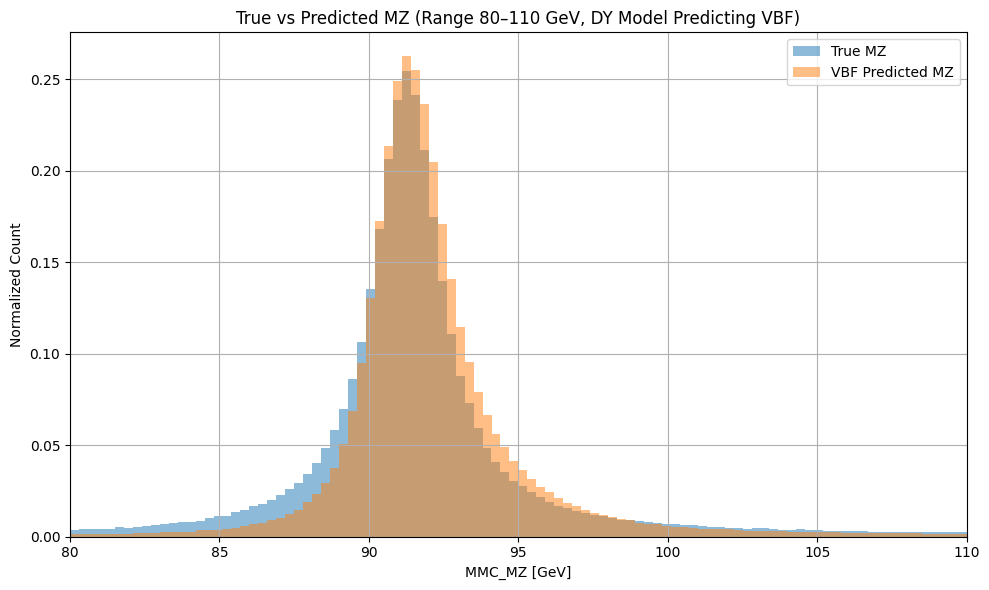

In [26]:
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cpu")
batch_size = 1024  # Tune this based on your GPU RAM
inference_dataset = TensorDataset(X_tensor, Extra_tensor)
inference_loader = DataLoader(inference_dataset, batch_size=batch_size)

predictions = []

model.eval()
with torch.no_grad():
    for x_batch, extra_batch in inference_loader:
        x_batch = x_batch.to(device)  # If you're using GPU
        extra_batch = extra_batch.to(device)
        
        y_pred = model(x_batch, extra_batch)
        predictions.append(y_pred.cpu())  # move to CPU to save GPU RAM

dy_predictions = torch.cat(predictions).squeeze().numpy()
dy_predictions = targetScaler.inverse_transform(dy_predictions.reshape(-1, 1))

    
import matplotlib.pyplot as plt
import numpy as np

# Define desired range
mz_min, mz_max = 80, 110


targets = targetScaler.inverse_transform(Y_tensor.reshape(-1, 1))
print(targets.shape)
print(targets)


# Filter values to be within [80, 110]
true_filtered = targets[(targets >= mz_min) & (targets <= mz_max)]
dy_pred_filtered = dy_predictions[(dy_predictions >= mz_min) & (dy_predictions <= mz_max)]
#vbf_pred_filtered = vbf_predictions[(vbf_predictions >= mz_min) & (vbf_predictions <= mz_max)]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(true_filtered, bins=100, alpha=0.5, label='True MZ', density=True)
plt.hist(dy_pred_filtered, bins=100, alpha=0.5, label='VBF Predicted MZ', density=True)
#plt.hist(vbf_pred_filtered, bins=100, alpha=0.5, label='VBF Predicted MZ', density=True)

plt.xlabel("MMC_MZ [GeV]")
plt.ylabel("Normalized Count")
plt.title("True vs Predicted MZ (Range 80–110 GeV, DY Model Predicting VBF)")
plt.legend()
plt.grid(True)
plt.xlim(mz_min, mz_max)
plt.tight_layout()
plt.show()

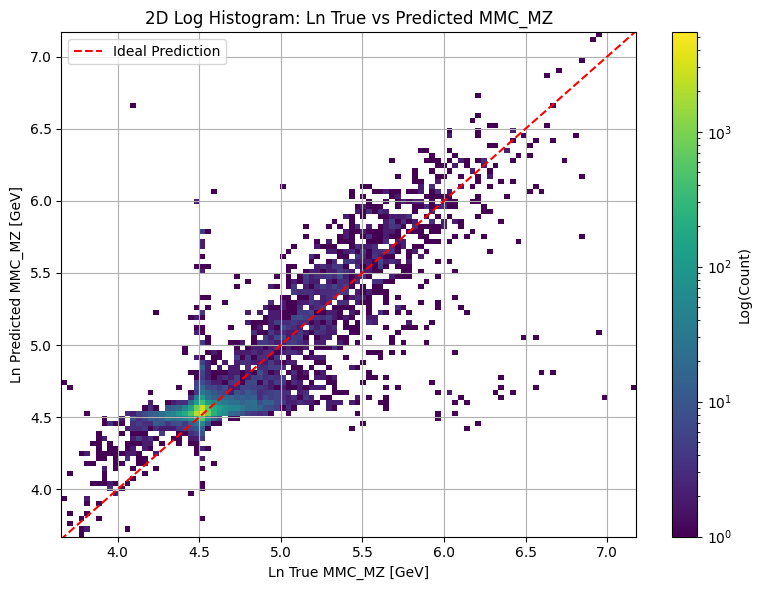

In [21]:
plt.figure(figsize=(8, 6))
x = targets.flatten()
y = dy_predictions.flatten()

# 2D histogram with log color scale
plt.hist2d(np.log(x), np.log(y), bins=100,
           norm=colors.LogNorm(), cmap='viridis')

plt.colorbar(label="Log(Count)")
plt.xlabel("Ln True MMC_MZ [GeV]")
plt.ylabel("Ln Predicted MMC_MZ [GeV]")
plt.title("2D Log Histogram: Ln True vs Predicted MMC_MZ")
plt.grid(True)
plt.plot([0, 10], [0, 10], 'r--', label='Ideal Prediction')
plt.legend()
plt.tight_layout()
plt.show()

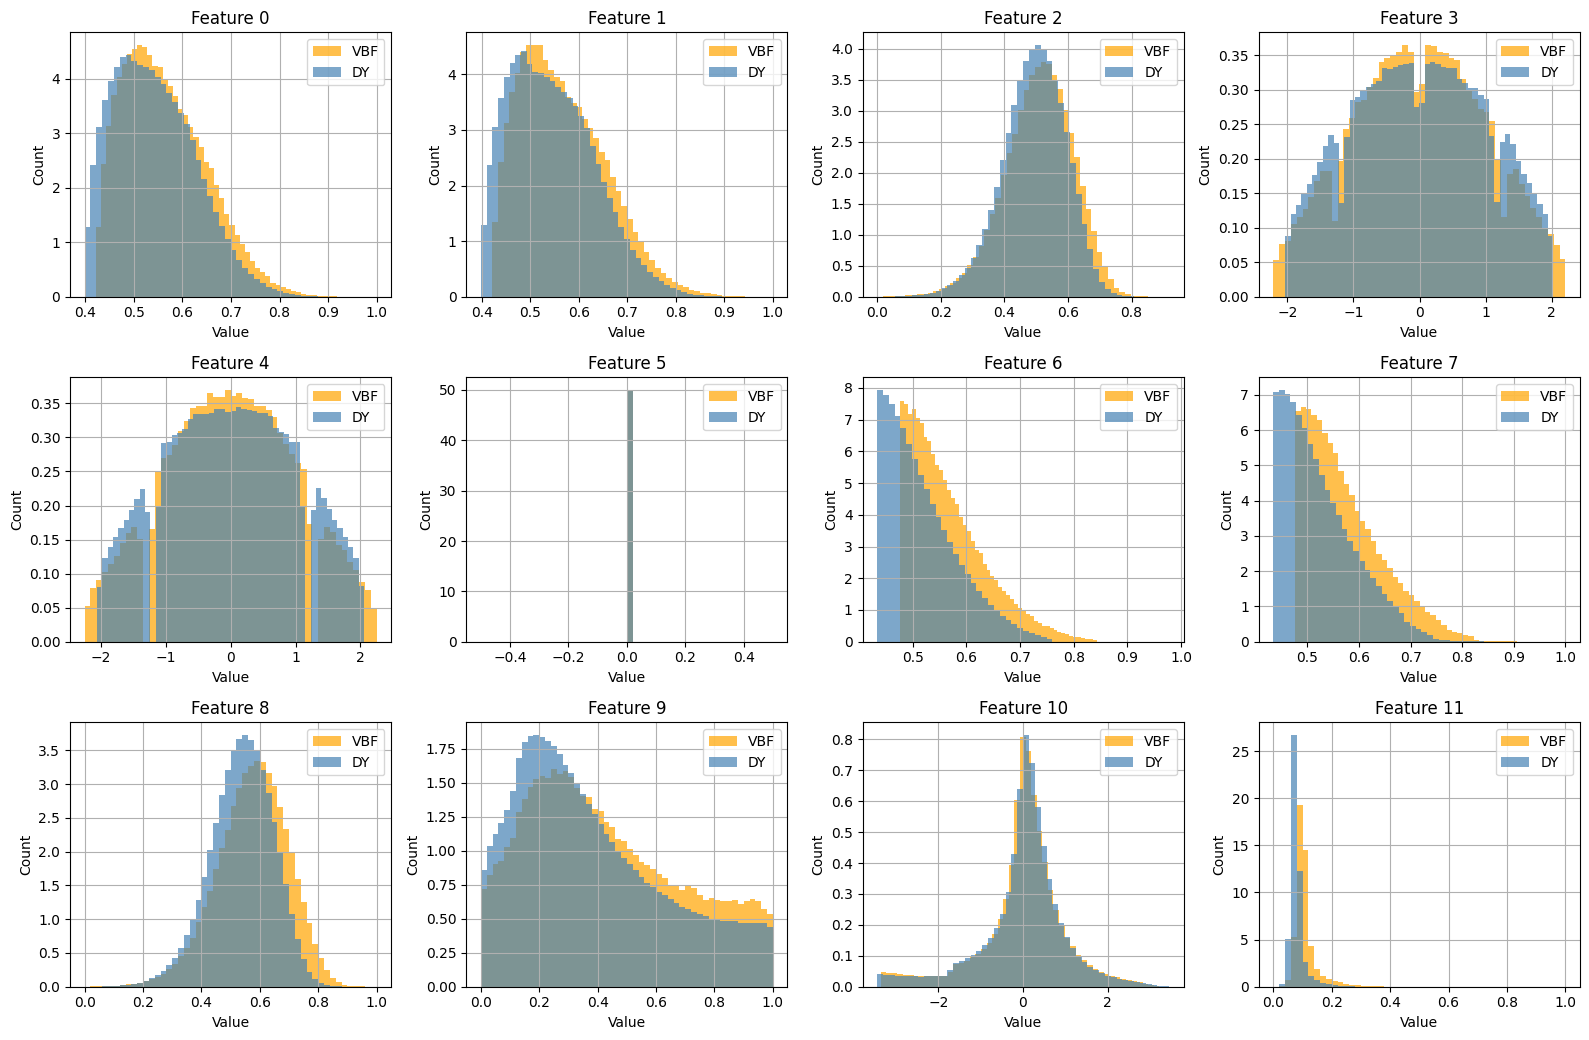

In [60]:
import matplotlib.pyplot as plt
import torch

# Ensure it's a numpy array for easier plotting
X_np = X_tensor.numpy()
VBF_np = VBF_tensor.numpy()

n_features = X_np.shape[1]
n_cols = 4  # number of plots per row
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.hist(VBF_np[:, i], bins=50, color='orange', alpha=0.7, density=True, label='VBF')
    plt.hist(X_np[:, i], bins=50, color='steelblue', alpha=0.7, density=True, label='DY')
    plt.title(f'Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


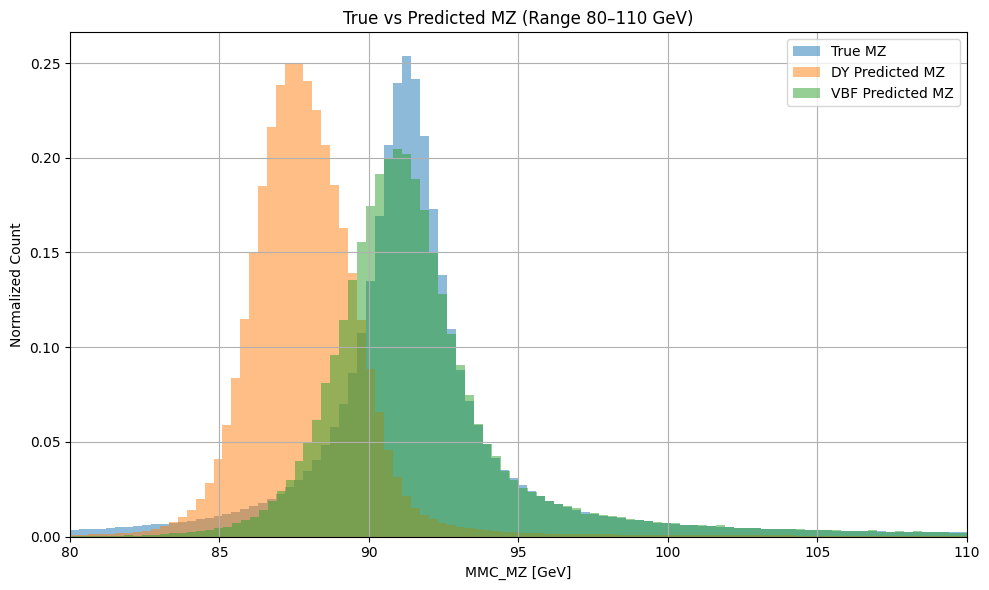

In [61]:

# 4. Run predictions
with torch.no_grad():
    dy_predictions = model(X_tensor).squeeze().cpu().numpy()  # shape: (n_samples,)
    vbf_predictions = model(VBF_tensor).squeeze().cpu().numpy()  # shape: (n_samples,)

import matplotlib.pyplot as plt
import numpy as np

# Define desired range
mz_min, mz_max = 80, 110

# Filter values to be within [80, 110]
true_filtered = true_targets[(true_targets >= mz_min) & (true_targets <= mz_max)]
dy_pred_filtered = dy_predictions[(dy_predictions >= mz_min) & (dy_predictions <= mz_max)]
vbf_pred_filtered = vbf_predictions[(vbf_predictions >= mz_min) & (vbf_predictions <= mz_max)]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(true_filtered, bins=100, alpha=0.5, label='True MZ', density=True)
plt.hist(dy_pred_filtered, bins=100, alpha=0.5, label='DY Predicted MZ', density=True)
plt.hist(vbf_pred_filtered, bins=100, alpha=0.5, label='VBF Predicted MZ', density=True)

plt.xlabel("MMC_MZ [GeV]")
plt.ylabel("Normalized Count")
plt.title("True vs Predicted MZ (Range 80–110 GeV)")
plt.legend()
plt.grid(True)
plt.xlim(mz_min, mz_max)
plt.tight_layout()
plt.show()

In [62]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# First split: train + val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_tensor, true_targets, test_size=0.2, random_state=42)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42)

batch_size = 8192  # you can adjust this

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, torch.tensor(y_val, dtype=torch.float32)), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test, torch.tensor(y_test, dtype=torch.float32)), batch_size=batch_size)

# Move model to device
model = model.to(device)

criterion = nn.SmoothL1Loss(reduction='mean', beta=10.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

n_epochs = 5
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    epoch_train_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_X).squeeze()
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = 0
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_preds = model(val_X).squeeze()
            val_loss += criterion(val_preds, val_y).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss:.4f}", end='\r')


Using device: cuda
Epoch 5/5 | Train Loss: 4.9847 | Val Loss: 4.2635

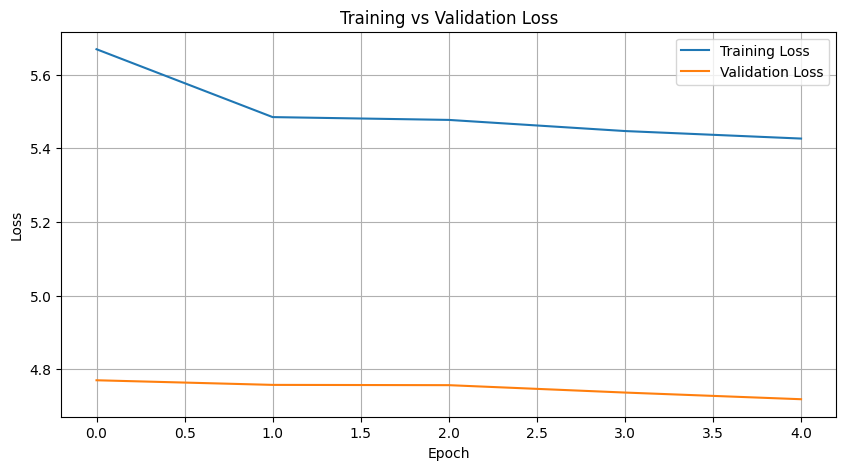

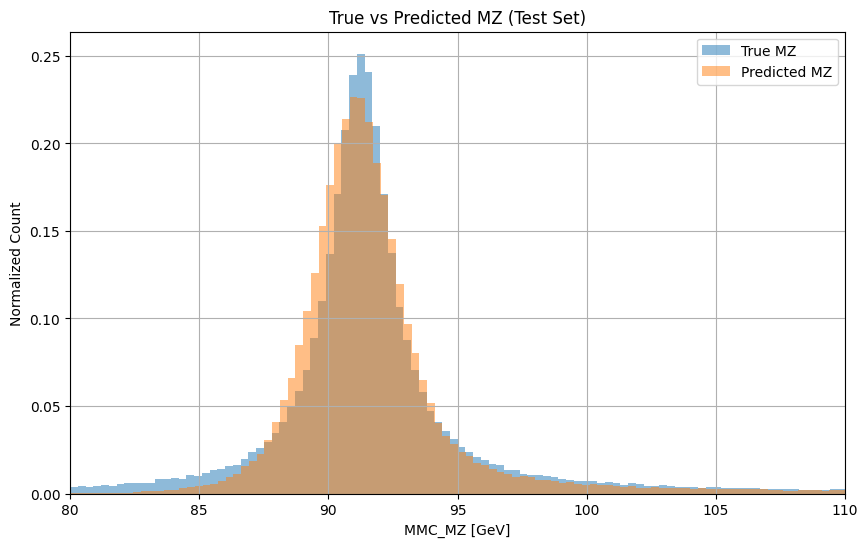

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Switch model to eval mode
model.eval()

# Run on test set
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X).squeeze().cpu().numpy()
        targets = batch_y.numpy()
        all_preds.extend(preds)
        all_targets.extend(targets)

# Convert to NumPy arrays
import numpy as np
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Mask to select values in [80, 110]
pred_mask = (all_preds >= 80) & (all_preds <= 110)
target_mask = (all_targets >= 80) & (all_targets <= 110)

filtered_targets = all_targets[target_mask]
filtered_preds = all_preds[pred_mask]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(filtered_targets, bins=100, alpha=0.5, label='True MZ', density=True)
plt.hist(filtered_preds, bins=100, alpha=0.5, label='Predicted MZ', density=True)

plt.xlabel("MMC_MZ [GeV]")
plt.ylabel("Normalized Count")
plt.title("True vs Predicted MZ (Test Set)")
plt.legend()
plt.grid(True)
plt.xlim(80, 110)
plt.show()


        predictions      labels
0         89.292076   91.088104
1         86.862129   91.305412
2         86.232574   90.802818
3         85.491585   86.972153
4         88.540382   89.950676
...             ...         ...
287347    89.964813  123.359215
287348    91.245384   90.298203
287349    87.212715   90.650131
287350    86.133614   79.920677
287351    87.732376   90.553848

[287352 rows x 2 columns]
        predictions      labels
0         89.292076   91.088104
1         86.862129   91.305412
2         86.232574   90.802818
3         85.491585   86.972153
4         88.540382   89.950676
...             ...         ...
287347    89.964813  123.359215
287348    91.245384   90.298203
287349    87.212715   90.650131
287350    86.133614   79.920677
287351    87.732376   90.553848

[287352 rows x 2 columns]
Data Statistics:
Number of samples: 287352

Labels:
  Mean: 98.4537
  Std:  40.7101
  Min:  20.3401
  Max:  2252.3198

Predictions:
  Mean: 225.8021
  Std:  74145.6423
  Min:  80

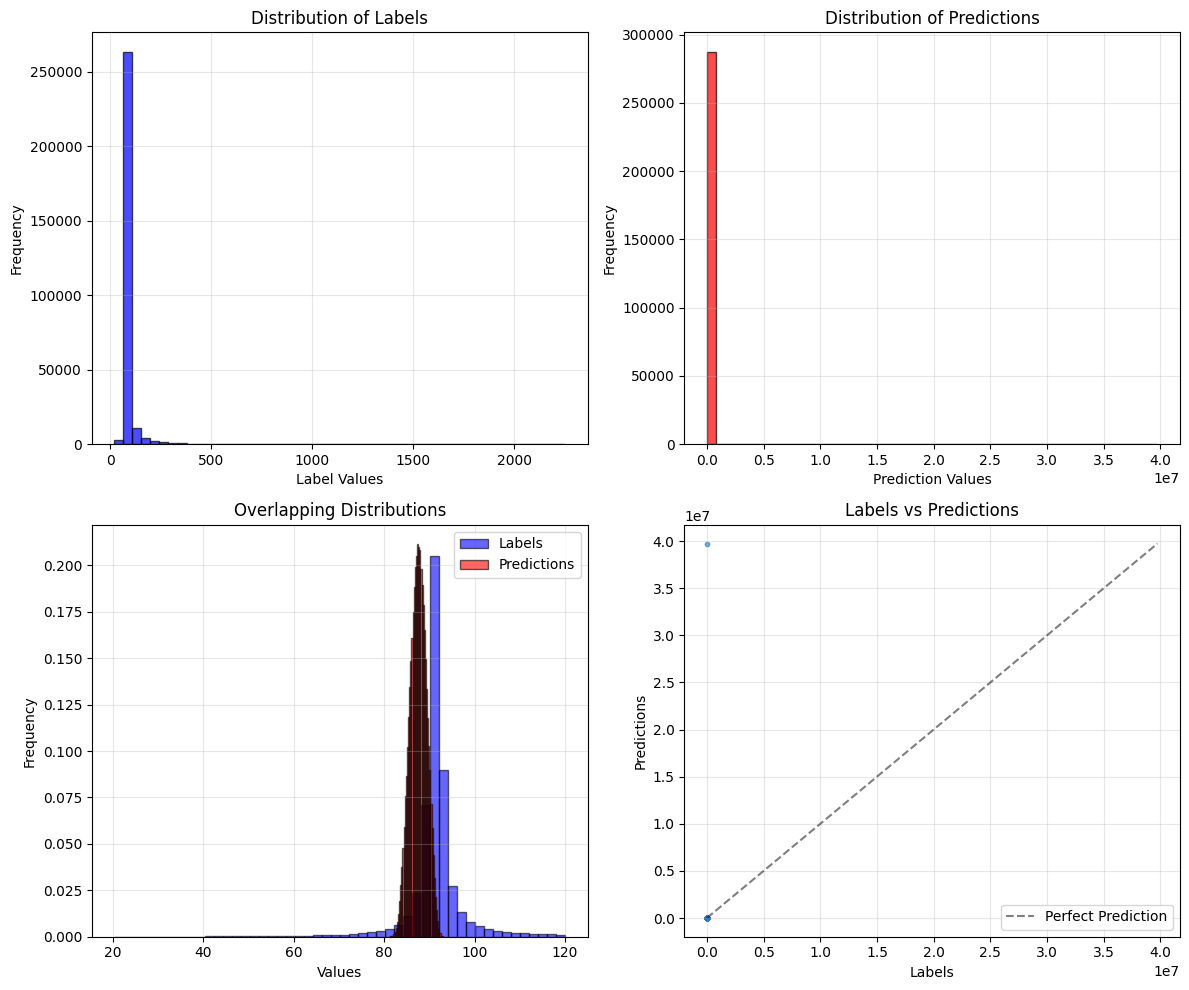

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions_histograms(csv_file_path):
    # Load the CSV file
    df = pd.read_csv(csv_file_path)

    print(df)
    
    # Check if required columns exist
    if 'labels' not in df.columns or 'predictions' not in df.columns:
        raise ValueError("CSV file must contain 'labels' and 'predictions' columns")
    
    # Extract the data
    labels = df['labels'].values
    predictions = df['predictions'].values
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot histogram for labels
    axes[0, 0].hist(labels, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].set_title('Distribution of Labels')
    axes[0, 0].set_xlabel('Label Values')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot histogram for predictions
    axes[0, 1].hist(predictions, bins=50, alpha=0.7, color='red', edgecolor='black')
    axes[0, 1].set_title('Distribution of Predictions')
    axes[0, 1].set_xlabel('Prediction Values')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot overlapping histograms
    axes[1, 0].hist(labels[ labels < 120 ], bins=50, alpha=0.6, color='blue', label='Labels', edgecolor='black', density=True)
    axes[1, 0].hist(predictions[ predictions < 120 ], bins=50, alpha=0.6, color='red', label='Predictions', edgecolor='black', density=True)
    axes[1, 0].set_title('Overlapping Distributions')
    axes[1, 0].set_xlabel('Values')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Scatter plot: labels vs predictions
    axes[1, 1].scatter(labels, predictions, alpha=0.6, s=10)
    axes[1, 1].set_title('Labels vs Predictions')
    axes[1, 1].set_xlabel('Labels')
    axes[1, 1].set_ylabel('Predictions')
    
    # Add perfect prediction line (y=x)
    min_val = min(min(labels), min(predictions))
    max_val = max(max(labels), max(predictions))
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    
    # Print some statistics
    print(f"Data Statistics:")
    print(f"Number of samples: {len(labels)}")
    print(f"\nLabels:")
    print(f"  Mean: {np.mean(labels):.4f}")
    print(f"  Std:  {np.std(labels):.4f}")
    print(f"  Min:  {np.min(labels):.4f}")
    print(f"  Max:  {np.max(labels):.4f}")
    print(f"\nPredictions:")
    print(f"  Mean: {np.mean(predictions):.4f}")
    print(f"  Std:  {np.std(predictions):.4f}")
    print(f"  Min:  {np.min(predictions):.4f}")
    print(f"  Max:  {np.max(predictions):.4f}")
    
    # Calculate correlation and MAE
    correlation = np.corrcoef(labels, predictions)[0, 1]
    mae = np.mean(np.abs(labels - predictions))
    mse = np.mean((labels - predictions)**2)
    rmse = np.sqrt(mse)
    
    print(f"\nModel Performance:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  MAE:         {mae:.4f}")
    print(f"  MSE:         {mse:.4f}")
    print(f"  RMSE:        {rmse:.4f}")
    
    # Show the plot
    plt.show()
    
    return fig
    
import re
    
# Replace with your CSV file path
csv_file_path = "../results/Test_mzmmc_DY/predictions.csv"  # Change this to your file path
#csv_file_path = "../Training_predictions.csv"  # Change this to your file path


df = pd.read_csv(csv_file_path)
print(df)


fig = plot_predictions_histograms(csv_file_path)